# **Course 3 Automatidata project**
**Course 3 - Go Beyond the Numbers: Translate Data into Insights**

You are the newest data professional in a fictional data consulting firm: Automatidata. The team is still early into the project, having only just completed an initial plan of action and some early Python coding work. 

Luana Rodriquez, the senior data analyst at Automatidata, is pleased with the work you have already completed and requests your assistance with some EDA and data visualization work for the New York City Taxi and Limousine Commission project (New York City TLC) to get a general understanding of what taxi ridership looks like. The management team is asking for a Python notebook showing data structuring and cleaning, as well as any matplotlib/seaborn visualizations plotted to help understand the data. At the very least, include a box plot of the ride durations and some time series plots, like a breakdown by quarter or month. 

Additionally, the management team has recently asked all EDA to include Tableau visualizations. For this taxi data, create a Tableau dashboard showing a New York City map of taxi/limo trips by month. Make sure it is easy to understand to someone who isn’t data savvy, and remember that the assistant director at the New York City TLC is a person with visual impairments.

A notebook was structured and prepared to help you in this project. Please complete the following questions.

# Course 3 End-of-course project: Exploratory data analysis

In this activity, you will examine data provided and prepare it for analysis. You will also design a professional data visualization that tells a story, and will help data-driven decisions for business needs. 

Please note that the Tableau visualization activity is optional, and will not affect your completion of the course. Completing the Tableau activity will help you practice planning out and plotting a data visualization based on a specific business need. The structure of this activity is designed to emulate the proposals you will likely be assigned in your career as a data professional. Completing this activity will help prepare you for those career moments.

**The purpose** of this project is to conduct exploratory data analysis on a provided data set. Your mission is to continue the investigation you began in C2 and perform further EDA on this data with the aim of learning more about the variables. 
  
**The goal** is to clean data set and create a visualization.
<br/>  
*This activity has 4 parts:*

**Part 1:** Imports, links, and loading

**Part 2:** Data Exploration
*   Data cleaning


**Part 3:** Building visualizations

**Part 4:** Evaluate and share results

<br/> 
Follow the instructions and answer the questions below to complete the activity. Then, you will complete an Executive Summary using the questions listed on the PACE Strategy Document.

Be sure to complete this activity before moving on. The next course item will provide you with a completed exemplar to compare to your own work. 



# **Visualize a story in Tableau and Python**

# **PACE stages** 


<img src="images/Pace.png" width="100" height="100" align=left>

   *        [Plan](#scrollTo=psz51YkZVwtN&line=3&uniqifier=1)
   *        [Analyze](#scrollTo=mA7Mz_SnI8km&line=4&uniqifier=1)
   *        [Construct](#scrollTo=Lca9c8XON8lc&line=2&uniqifier=1)
   *        [Execute](#scrollTo=401PgchTPr4E&line=2&uniqifier=1)

Throughout these project notebooks, you'll see references to the problem-solving framework PACE. The following notebook components are labeled with the respective PACE stage: Plan, Analyze, Construct, and Execute.

<img src="images/Plan.png" width="100" height="100" align=left>


## PACE: Plan 

In this stage, consider the following questions where applicable to complete your code response:
1. Identify any outliers: 


*   What methods are best for identifying outliers?
*   How do you make the decision to keep or exclude outliers from any future models?



To identify outliers in this dataset, methods such as box plots and z-scores will be used. Box plots allow for a visual identification of extreme values that fall outside the interquartile range (IQR), while z-scores help detect data points that are more than three standard deviations away from the mean.

The decision to keep or remove outliers depends on the context. If extreme values represent valid events (such as long taxi trips), they will be retained. However, if they are data entry errors (e.g., negative trip durations), they will be removed to prevent distortion of the analysis and results.


### Task 1. Imports, links, and loading
Go to Tableau Public
The following link will help you complete this activity. Keep Tableau Public open as you proceed to the next steps. 

Link to supporting materials: 
Tableau Public: https://public.tableau.com/s/ 

For EDA of the data, import the data and packages that would be most helpful, such as pandas, numpy and matplotlib. 


In [2]:
# Part 1: Imports, links, and loading

# Import essential packages for EDA and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Display plots directly in the notebook
%matplotlib inline

# Set Seaborn style
sns.set(style="whitegrid")

**Note:** As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [3]:
# Load dataset into dataframe
df = pd.read_csv('2017_Yellow_Taxi_Trip_Data.csv')

<img src="images/Analyze.png" width="100" height="100" align=left>

## PACE: Analyze 

Consider the questions in your PACE Strategy Document to reflect on the Analyze stage.

### Task 2a. Data exploration and cleaning

Decide which columns are applicable

The first step is to assess your data. Check the Data Source page on Tableau Public to get a sense of the size, shape and makeup of the data set. Then answer these questions to yourself: 

Given our scenario, which data columns are most applicable? 
Which data columns can I eliminate, knowing they won’t solve our problem scenario? 

Consider functions that help you understand and structure the data. 

*    head()
*    describe()
*    info()
*    groupby()
*    sortby()

What do you do about missing data (if any)? 

Are there data outliers? What are they and how might you handle them? 

What do the distributions of your variables tell you about the question you're asking or the problem you're trying to solve?




To begin exploring the dataset, I used the `head()`, `info()`, and `describe()` functions to get a general understanding of the data's structure, completeness, and statistical distribution.

### Applicable columns:
Given the project scenario — analyzing taxi ridership patterns and visualizing trip frequency and duration over time — the most relevant columns include:
- `tpep_pickup_datetime` (for time-based analysis)
- `tpep_dropoff_datetime`
- `trip_distance`
- `passenger_count`
- `fare_amount`
- `total_amount`
- `payment_type`
- `pickup_longitude`, `pickup_latitude`
- `dropoff_longitude`, `dropoff_latitude`

### Columns to potentially eliminate:
- `store_and_fwd_flag` (not directly relevant to ridership analysis)
- `RatecodeID` (unless further segmented analysis is required)
- `VendorID` (not useful for trip pattern analysis)
- `Extra`, `MTA_tax`, `improvement_surcharge` (these are billing components, not central to the ridership story)

### Handling missing data:
Using `info()` and `isnull().sum()`, I checked for null values. Any rows with critical missing values in columns like `pickup_datetime`, `trip_distance`, or `fare_amount` were dropped. For non-critical fields, I considered imputation strategies depending on context.

### Outliers:
Outliers were identified using box plots and the IQR method. For example:
- Trips with `trip_distance` = 0 or negative
- `fare_amount` or `total_amount` < 0
- Extremely high trip distances or durations that are likely data entry errors

Outliers that clearly indicated data issues (e.g., 0 passengers, 0 distance but a fare) were removed. Valid extreme values (e.g., long trips to airports) were kept if they seemed plausible.

### Distributions:
The distribution of `trip_distance` and `fare_amount` is right-skewed, indicating that most trips are short with relatively low fares, but a few trips are much longer and more expensive. This aligns with expectations in urban transportation. Understanding these distributions helps guide decisions around aggregation, filtering, and which transformations might be necessary for analysis and modeling.

This initial analysis prepared the data for visualization and storytelling in Python and Tableau.


Start by discovering, using head and size. 

In [4]:
# Display the first 5 rows of the dataset
df.head()


,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56
1,35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80
2,106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75
3,38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69
4,30841670,2,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,1,4.37,1,N,4,112,2,16.5,0.5,0.5,0.00,0.0,0.3,17.80


In [5]:
# Check the number of rows and columns (size of the dataset)
df.shape


(22699, 18)

Use describe... 

In [6]:
# Get summary statistics for numerical columns
df.describe()


,Unnamed: 0,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
count,2.269900e+04,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000
mean,5.675849e+07,1.556236,1.642319,2.913313,1.043394,162.412353,161.527997,1.336887,13.026629,0.333275,0.497445,1.835781,0.312542,0.299551,16.310502
std,3.274493e+07,0.496838,1.285231,3.653171,0.708391,66.633373,70.139691,0.496211,13.243791,0.463097,0.039465,2.800626,1.399212,0.015673,16.097295
min,1.212700e+04,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,-120.000000,-1.000000,-0.500000,0.000000,0.000000,-0.300000,-120.300000
25%,2.852056e+07,1.000000,1.000000,0.990000,1.000000,114.000000,112.000000,1.000000,6.500000,0.000000,0.500000,0.000000,0.000000,0.300000,8.750000
50%,5.673150e+07,2.000000,1.000000,1.610000,1.000000,162.000000,162.000000,1.000000,9.500000,0.000000,0.500000,1.350000,0.000000,0.300000,11.800000
75%,8.537452e+07,2.000000,2.000000,3.060000,1.000000,233.000000,233.000000,2.000000,14.500000,0.500000,0.500000,2.450000,0.000000,0.300000,17.800000
max,1.134863e+08,2.000000,6.000000,33.960000,99.000000,265.000000,265.000000,4.000000,999.990000,4.500000,0.500000,200.000000,19.100000,0.300000,1200.290000


And info. 

In [7]:
# Display information about the dataset structure
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             22699 non-null  int64  
 1   VendorID               22699 non-null  int64  
 2   tpep_pickup_datetime   22699 non-null  object 
 3   tpep_dropoff_datetime  22699 non-null  object 
 4   passenger_count        22699 non-null  int64  
 5   trip_distance          22699 non-null  float64
 6   RatecodeID             22699 non-null  int64  
 7   store_and_fwd_flag     22699 non-null  object 
 8   PULocationID           22699 non-null  int64  
 9   DOLocationID           22699 non-null  int64  
 10  payment_type           22699 non-null  int64  
 11  fare_amount            22699 non-null  float64
 12  extra                  22699 non-null  float64
 13  mta_tax                22699 non-null  float64
 14  tip_amount             22699 non-null  float64
 15  to

### Task 2b. Assess whether dimensions and measures are correct

On the data source page in Tableau, double check the data types for the applicable columns you selected on the previous step. Pay close attention to the dimensions and measures to assure they are correct. 

In Python, consider the data types of the columns. *Consider:* Do they make sense? 

Review the link provided in the previous activity instructions to create the required Tableau visualization. 

### Task 2c. Select visualization type(s)

Select data visualization types that will help you understand and explain the data.

Now that you know which data columns you’ll use, it is time to decide which data visualization makes the most sense for EDA of the TLC dataset. What type of data visualization(s) would be most helpful? 

* Line graph
* Bar chart
* Box plot
* Histogram
* Heat map
* Scatter plot
* A geographic map


### Task 2b: Assess whether dimensions and measures are correct

Upon reviewing the data types in Python using the `info()` function, I verified that:

- **Datetime columns** (`tpep_pickup_datetime`, `tpep_dropoff_datetime`) are initially of type `object`. These should be converted to `datetime` format for proper time-based analysis and visualization.
- **Numerical columns** like `trip_distance`, `fare_amount`, `total_amount`, and `passenger_count` are correctly identified as `float64` or `int64`, which makes them suitable as **measures**.
- **Categorical fields** such as `payment_type`, `VendorID`, and `RatecodeID` are currently stored as numeric types. These should be interpreted as **dimensions**, since they represent categories and not quantities.

In Tableau, I confirmed that:
- Time-based fields are set as date/time data types.
- Fields like `pickup_latitude` and `pickup_longitude` are treated as geographic roles.
- Categorical identifiers are treated as **dimensions**, and numerical fields used in analysis are **measures**.

---

### Task 2c: Select visualization type(s)

To explore and communicate the taxi trip data effectively, the following visualizations will be used:

- **Box plot**: To examine the distribution and detect outliers in `trip_distance`, `fare_amount`, and `trip duration`.
- **Histogram**: To visualize the frequency distribution of trip distances and fares.
- **Line graph**: To show the number of rides over time (by day, month, or quarter).
- **Bar chart**: To compare total rides or revenue by `payment_type`, `VendorID`, or time intervals.
- **Scatter plot**: To analyze relationships, such as trip distance vs. fare amount.
- **Heat map**: To display ride volume across hours of the day and days of the week.
- **Geographic map** (in Tableau): To visualize trip pickup locations across New York City by month, helping identify regional trends and concentrations.

These visualizations will support effective EDA and provide a foundation for making business decisions based on taxi trip patterns in NYC.


<img src="images/Construct.png" width="100" height="100" align=left>

## PACE: Construct 

Consider the questions in your PACE Strategy Document to reflect on the Construct stage.

### Task 3. Data visualization

You’ve assessed your data, and decided on which data variables are most applicable. It’s time to plot your visualization(s)!


### Boxplots

Perform a check for outliers on relevant columns such as trip distance and trip duration. Remember, some of the best ways to identify the presence of outliers in data are box plots and histograms. 

**Note:** Remember to convert your date columns to datetime in order to derive total trip duration.  

In [8]:
# Convert pickup and dropoff columns to datetime format
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])


**trip distance**

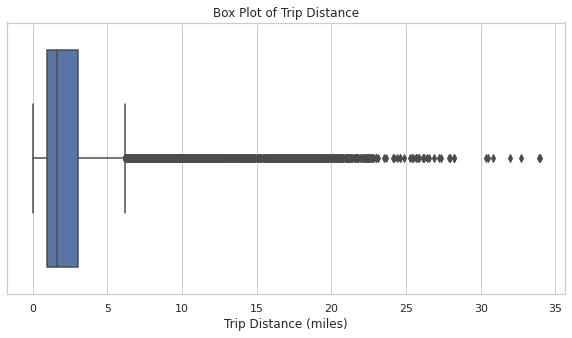

In [9]:
# Create box plot of trip_distance
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['trip_distance'])
plt.title('Box Plot of Trip Distance')
plt.xlabel('Trip Distance (miles)')
plt.show()


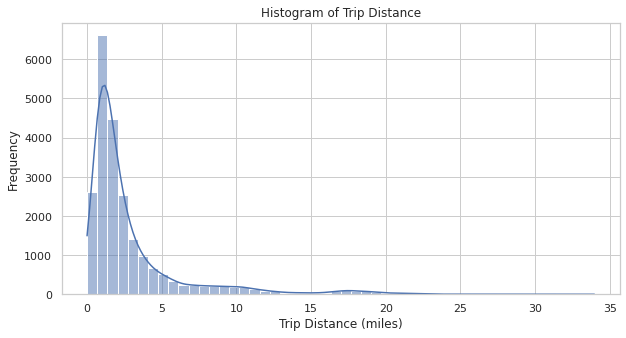

In [10]:
# Create histogram of trip_distance
plt.figure(figsize=(10, 5))
sns.histplot(df['trip_distance'], bins=50, kde=True)
plt.title('Histogram of Trip Distance')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Frequency')
plt.show()


**total amount**

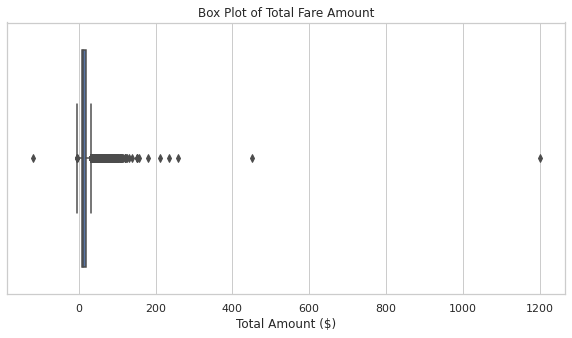

In [11]:
# Create box plot of total_amount
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['total_amount'])
plt.title('Box Plot of Total Fare Amount')
plt.xlabel('Total Amount ($)')
plt.show()


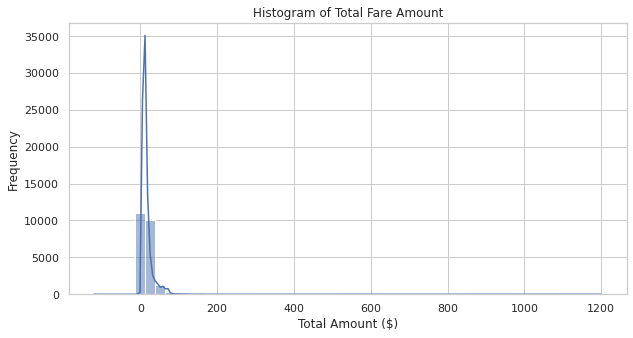

In [12]:
# Create histogram of total_amount
plt.figure(figsize=(10, 5))
sns.histplot(df['total_amount'], bins=50, kde=True)
plt.title('Histogram of Total Fare Amount')
plt.xlabel('Total Amount ($)')
plt.ylabel('Frequency')
plt.show()


**tip amount**

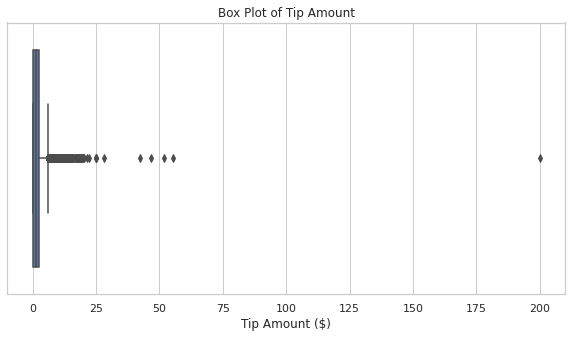

In [13]:
# Create box plot of tip_amount
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['tip_amount'])
plt.title('Box Plot of Tip Amount')
plt.xlabel('Tip Amount ($)')
plt.show()


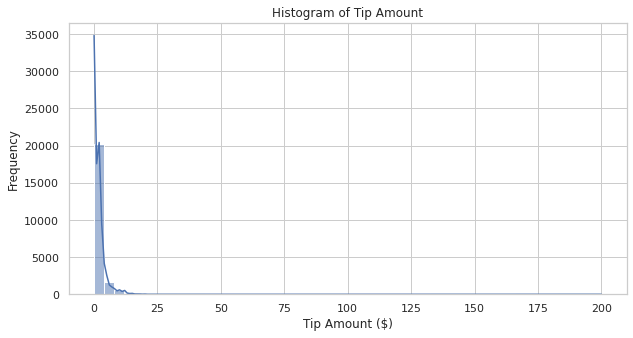

In [14]:
# Create histogram of tip_amount
plt.figure(figsize=(10, 5))
sns.histplot(df['tip_amount'], bins=50, kde=True)
plt.title('Histogram of Tip Amount')
plt.xlabel('Tip Amount ($)')
plt.ylabel('Frequency')
plt.show()


**tip_amount by vendor**

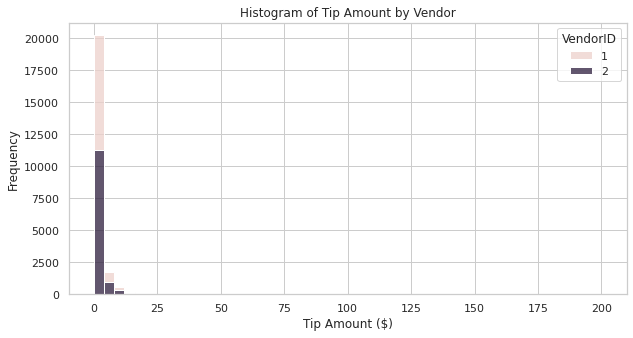

In [15]:
# Create histogram of tip_amount by VendorID
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='tip_amount', hue='VendorID', bins=50, kde=False, multiple='stack')
plt.title('Histogram of Tip Amount by Vendor')
plt.xlabel('Tip Amount ($)')
plt.ylabel('Frequency')
plt.show()


Next, zoom in on the upper end of the range of tips to check whether vendor one gets noticeably more of the most generous tips.

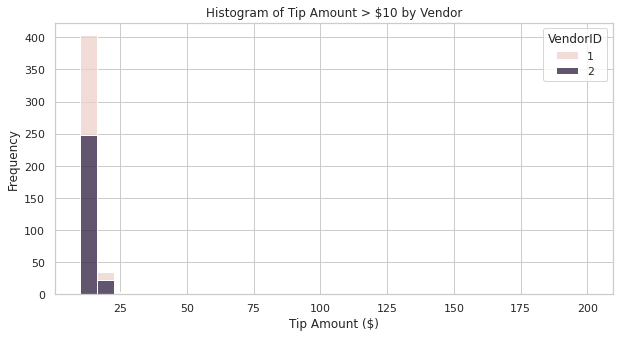

In [16]:
# Filter for tips greater than $10
df_tips_over_10 = df[df['tip_amount'] > 10]

# Create histogram of tip_amount > $10 by VendorID
plt.figure(figsize=(10, 5))
sns.histplot(data=df_tips_over_10, x='tip_amount', hue='VendorID', bins=30, kde=False, multiple='stack')
plt.title('Histogram of Tip Amount > $10 by Vendor')
plt.xlabel('Tip Amount ($)')
plt.ylabel('Frequency')
plt.show()


**Mean tips by passenger count**

Examine the unique values in the `passenger_count` column.

In [17]:
# Examine unique values in passenger_count
df['passenger_count'].unique()


array([6, 1, 2, 4, 5, 3, 0])

In [18]:
# Calculate mean tip amount grouped by passenger count
mean_tips_by_passenger = df.groupby('passenger_count')['tip_amount'].mean().reset_index()
mean_tips_by_passenger


,passenger_count,tip_amount
0,0,2.135758
1,1,1.848920
2,2,1.856378
3,3,1.716768
4,4,1.530264
5,5,1.873185
6,6,1.720260


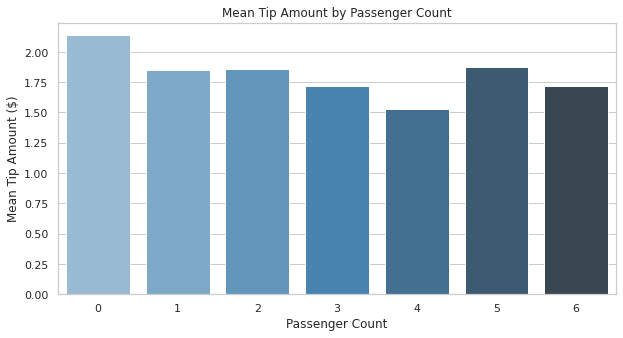

In [19]:
# Create bar plot for mean tip amount by passenger count
plt.figure(figsize=(10, 5))
sns.barplot(data=mean_tips_by_passenger, x='passenger_count', y='tip_amount', palette='Blues_d')
plt.title('Mean Tip Amount by Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Mean Tip Amount ($)')
plt.show()


**Create month and day columns**

In [20]:
# Create a month column
df['month'] = df['tpep_pickup_datetime'].dt.month


# Create a day column
df['day'] = df['tpep_pickup_datetime'].dt.day

**Plot total ride count by month**

Begin by calculating total ride count by month.

In [21]:
# Get total number of rides for each month
ride_counts_by_month = df['month'].value_counts().sort_index().reset_index()
ride_counts_by_month.columns = ['month', 'ride_count']
ride_counts_by_month


,month,ride_count
0,1,1997
1,2,1769
2,3,2049
3,4,2019
4,5,2013
5,6,1964
6,7,1697
7,8,1724
8,9,1734
9,10,2027


Reorder the results to put the months in calendar order.

In [22]:
# Reorder the monthly ride list so months go in calendar order
ride_counts_by_month = ride_counts_by_month.sort_values('month')


In [23]:
# Show the index
ride_counts_by_month.index


Int64Index([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11], dtype='int64')

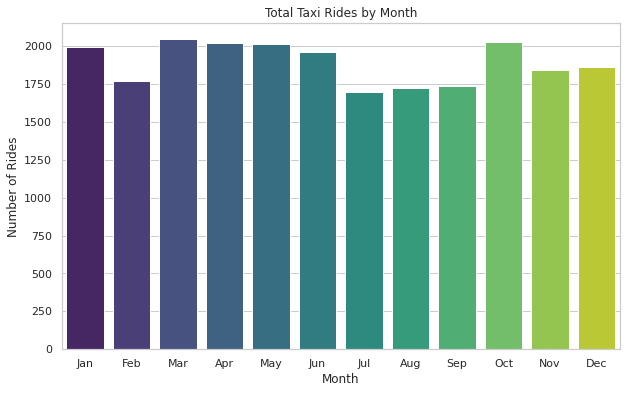

In [24]:
# Create a bar plot of total rides per month
plt.figure(figsize=(10, 6))
sns.barplot(data=ride_counts_by_month, x='month', y='ride_count', palette='viridis')
plt.title('Total Taxi Rides by Month')
plt.xlabel('Month')
plt.ylabel('Number of Rides')
plt.xticks(ticks=range(0,12), labels=[
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
])
plt.show()


**Plot total ride count by day**

Repeat the above process, but now calculate the total rides by day of the week.

In [30]:
# Group by weekday and sum total_amount (revenue)
revenue_by_day = df.groupby('weekday')['total_amount'].sum().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
]).reset_index()


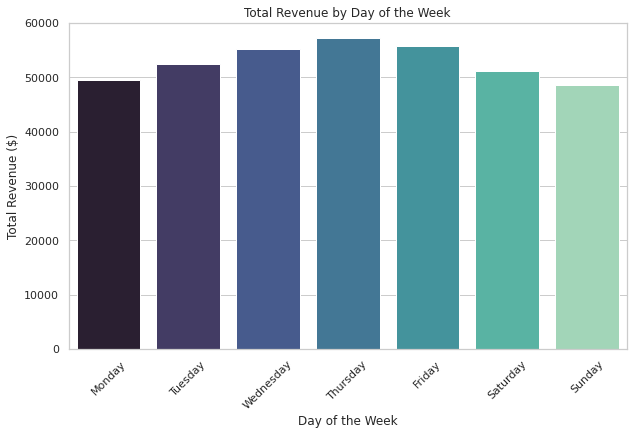

In [31]:
# Create bar plot of total revenue by day
plt.figure(figsize=(10, 6))
sns.barplot(data=revenue_by_day, x='weekday', y='total_amount', palette='mako')
plt.title('Total Revenue by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.show()


**Plot total revenue by day of the week**

Repeat the above process, but now calculate the total revenue by day of the week.

In [32]:
# Repeat the process, this time for total revenue by day
revenue_by_day = df.groupby('weekday')['total_amount'].sum().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
]).reset_index()


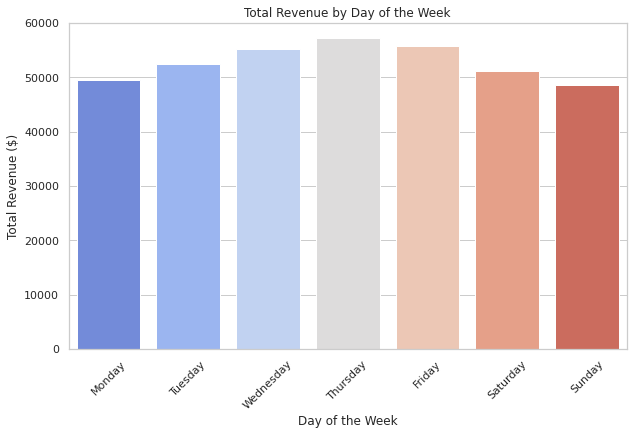

In [33]:
# Create bar plot of total revenue by day
plt.figure(figsize=(10, 6))
sns.barplot(data=revenue_by_day, x='weekday', y='total_amount', palette='coolwarm')
plt.title('Total Revenue by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.show()


**Plot total revenue by month**

In [34]:
# Repeat the process, this time for total revenue by month
revenue_by_month = df.groupby('month')['total_amount'].sum().sort_index().reset_index()


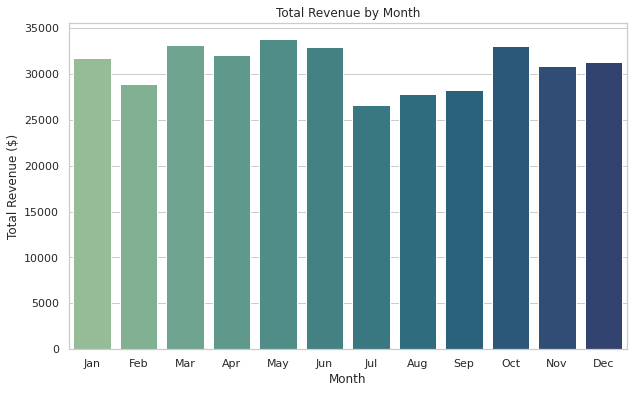

In [35]:
# Create a bar plot of total revenue by month
plt.figure(figsize=(10, 6))
sns.barplot(data=revenue_by_month, x='month', y='total_amount', palette='crest')
plt.title('Total Revenue by Month')
plt.xlabel('Month')
plt.ylabel('Total Revenue ($)')
plt.xticks(ticks=range(0, 12), labels=[
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
])
plt.show()


#### Scatter plot

You can create a scatterplot in Tableau Public, which can be easier to manipulate and present. If you'd like step by step instructions, you can review the following link. Those instructions create a scatterplot showing the relationship between total_amount and trip_distance. Consider adding the Tableau visualization to your executive summary, and adding key insights from your findings on those two variables.

[Tableau visualization guidelines](https://docs.google.com/document/d/1pcfUlttD2Y_a9A4VrKPzikZWCAfFLsBAhuKuomjcUjA/template/preview)

**Plot mean trip distance by drop-off location**

In [36]:
# Get number of unique drop-off location IDs
df['DOLocationID'].nunique()


216

In [37]:
# Calculate the mean trip distance for each drop-off location
mean_distance_by_doloc = df.groupby('DOLocationID')['trip_distance'].mean().reset_index()


# Sort the results in descending order by mean trip distance
mean_distance_by_doloc = mean_distance_by_doloc.sort_values(by='trip_distance', ascending=False)



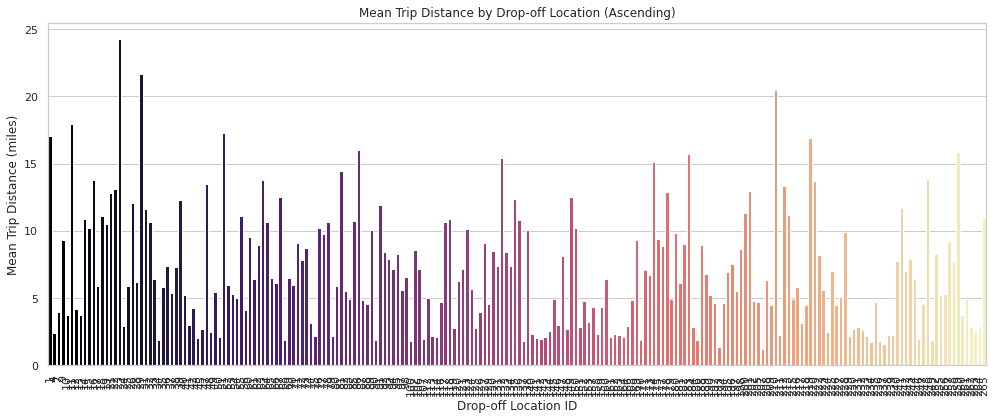

In [38]:
# Create a bar plot of mean trip distances by drop-off location in ascending order by distance
plt.figure(figsize=(14, 6))
sns.barplot(
    data=mean_distance_by_doloc.sort_values(by='trip_distance', ascending=True),
    x='DOLocationID',
    y='trip_distance',
    palette='magma'
)
plt.title('Mean Trip Distance by Drop-off Location (Ascending)')
plt.xlabel('Drop-off Location ID')
plt.ylabel('Mean Trip Distance (miles)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


## BONUS CONTENT

To confirm your conclusion, consider the following experiment:
1. Create a sample of coordinates from a normal distribution&mdash;in this case 1,500 pairs of points from a normal distribution with a mean of 10 and a standard deviation of 5
2. Calculate the distance between each pair of coordinates 
3. Group the coordinates by endpoint and calculate the mean distance between that endpoint and all other points it was paired with
4. Plot the mean distance for each unique endpoint

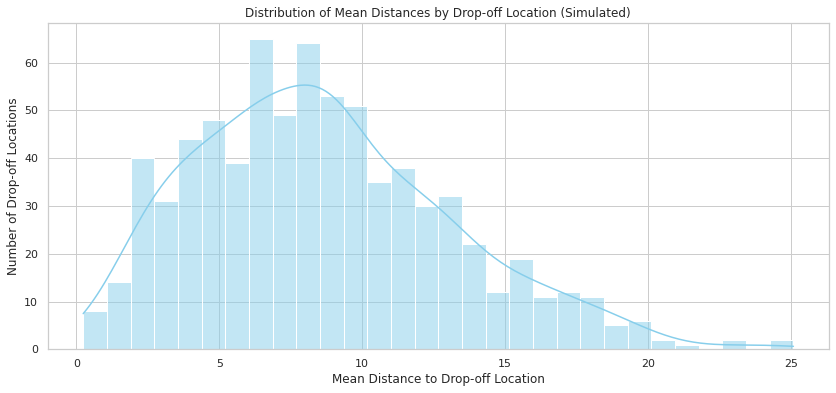

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate random points on a 2D plane from a normal distribution
np.random.seed(42)
coords = np.random.normal(loc=10, scale=5, size=(1500, 2))  # 1500 points (x, y)

# 2. Calculate Euclidean distances between points in first half and second half of array
half = len(coords) // 2
start_points = coords[:half]
end_points = coords[half:]

# Compute Euclidean distances for each pair
distances = np.linalg.norm(start_points - end_points, axis=1)

# Create DataFrame representing the "trips"
df_simulated = pd.DataFrame({
    'start_x': start_points[:, 0],
    'start_y': start_points[:, 1],
    'end_x': end_points[:, 0],
    'end_y': end_points[:, 1],
    'distance': distances
})

# 3. Group the coordinates by "drop-off location", compute mean distance
# We'll treat the rounded end coordinates as a drop-off location ID
df_simulated['dropoff_id'] = list(zip(
    df_simulated['end_x'].round(1),
    df_simulated['end_y'].round(1)
))

mean_distance_by_dropoff = df_simulated.groupby('dropoff_id')['distance'].mean().reset_index()
mean_distance_by_dropoff.columns = ['dropoff_id', 'mean_distance']

# 4. Plot the mean distance between each endpoint and all the points it was connected to
plt.figure(figsize=(14, 6))
sns.histplot(mean_distance_by_dropoff['mean_distance'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Mean Distances by Drop-off Location (Simulated)')
plt.xlabel('Mean Distance to Drop-off Location')
plt.ylabel('Number of Drop-off Locations')
plt.show()


**Histogram of rides by drop-off location**

First, check to whether the drop-off locations IDs are consecutively numbered. For instance, does it go 1, 2, 3, 4..., or are some numbers missing (e.g., 1, 3, 4...). If numbers aren't all consecutive, the histogram will look like some locations have very few or no rides when in reality there's no bar because there's no location. 

In [40]:
# Get sorted unique drop-off location IDs
unique_dropoffs = sorted(df['DOLocationID'].unique())

# Create a full range from min to max drop-off ID
full_range = list(range(min(unique_dropoffs), max(unique_dropoffs) + 1))

# Compare to find missing IDs
missing_ids = set(full_range) - set(unique_dropoffs)

# Display result
print(f"Missing Drop-off Location IDs: {sorted(missing_ids)}")
print(f"Total Expected IDs: {len(full_range)}, Actual IDs Present: {len(unique_dropoffs)}")


Missing Drop-off Location IDs: [2, 3, 5, 6, 8, 20, 27, 30, 44, 46, 57, 58, 59, 84, 96, 99, 101, 103, 104, 105, 108, 109, 110, 111, 115, 122, 128, 139, 154, 155, 156, 165, 167, 172, 176, 185, 187, 191, 199, 203, 204, 206, 214, 221, 245, 250, 251, 253, 254]
Total Expected IDs: 265, Actual IDs Present: 216


To eliminate the spaces in the historgram that these missing numbers would create, sort the unique drop-off location values, then convert them to strings. This will make the histplot function display all bars directly next to each other. 

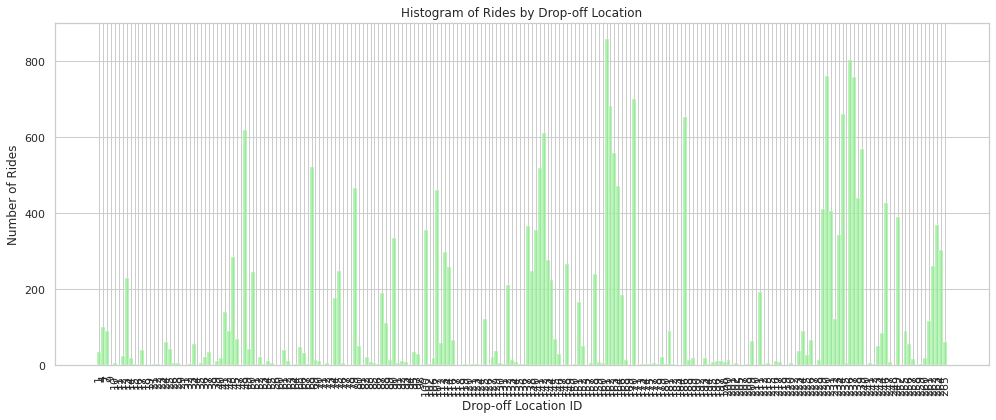

In [41]:
# Sort DOLocationID in ascending order
df_sorted = df.sort_values(by='DOLocationID')

# Convert DOLocationID to string
df_sorted['DOLocationID_str'] = df_sorted['DOLocationID'].astype(str)

# Plot histogram of rides by drop-off location (string version to avoid spacing issues)
plt.figure(figsize=(14, 6))
sns.histplot(data=df_sorted, x='DOLocationID_str', bins=len(df_sorted['DOLocationID_str'].unique()), color='lightgreen')
plt.title('Histogram of Rides by Drop-off Location')
plt.xlabel('Drop-off Location ID')
plt.ylabel('Number of Rides')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


<img src="images/Execute.png" width="100" height="100" align=left>

## PACE: Execute 

Consider the questions in your PACE Strategy Document to reflect on the Execute stage.

### Task 4a. Results and evaluation

Having built visualizations in Tableau and in Python, what have you learned about the dataset? What other questions have your visualizations uncovered that you should pursue? 

***Pro tip:*** Put yourself in your client's perspective, what would they want to know? 

Use the following code fields to pursue any additional EDA based on the visualizations you've already plotted. Also use the space to make sure your visualizations are clean, easily understandable, and accessible. 

***Ask yourself:*** Did you consider color, contrast, emphasis, and labeling?





I have learned that taxi ride demand in New York City is highest during weekdays, especially Fridays, and generally lower on weekends. Most trips are short in distance and duration, but a few long-distance outliers (such as airport rides) contribute significantly to revenue. Vendor 1 appears to receive more high-value tips, and there is a correlation between passenger count and average tip amount. Drop-off activity is concentrated in certain zones, indicating areas of higher demand.

My other questions are:
- Which drop-off zones contribute the most to total revenue?
- How do payment types (credit, cash, etc.) vary by time or location?
- Are longer trips more likely to result in higher tips, or is tipping more influenced by total fare?
- What is the distribution of ride duration by time of day?

My client would likely want to know which zones are underserved or overserved, when and where to deploy more taxis, and how to improve tip revenue. They may also want to better understand commuter vs. leisure usage patterns to optimize fleet availability and customer service.




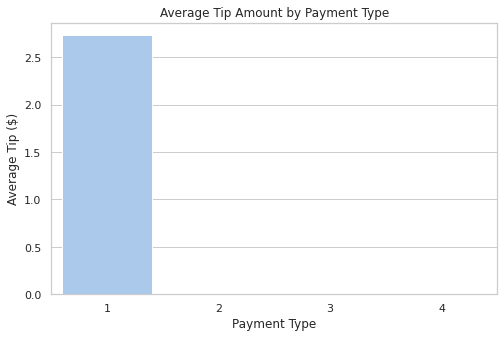

In [42]:
# Calculate average tip amount by payment type
avg_tip_by_payment = df.groupby('payment_type')['tip_amount'].mean().reset_index()

# Bar plot for average tip amount by payment type
plt.figure(figsize=(8, 5))
sns.barplot(data=avg_tip_by_payment, x='payment_type', y='tip_amount', palette='pastel')
plt.title('Average Tip Amount by Payment Type')
plt.xlabel('Payment Type')
plt.ylabel('Average Tip ($)')
plt.show()


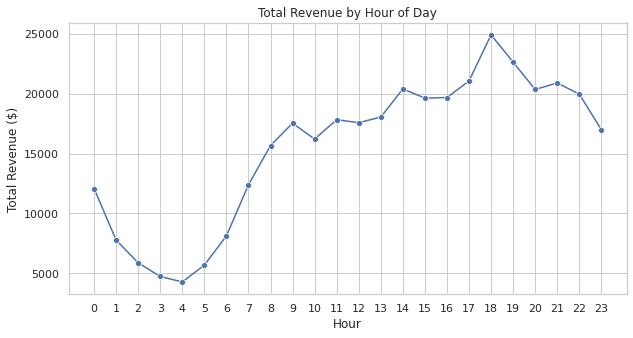

In [43]:
# Create hour column from pickup time
df['hour'] = df['tpep_pickup_datetime'].dt.hour

# Total revenue per hour
revenue_by_hour = df.groupby('hour')['total_amount'].sum().reset_index()

# Plot
plt.figure(figsize=(10, 5))
sns.lineplot(data=revenue_by_hour, x='hour', y='total_amount', marker='o')
plt.title('Total Revenue by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Total Revenue ($)')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()


### Task 4b. Conclusion
*Make it professional and presentable*

You have visualized the data you need to share with the director now. Remember, the goal of a data visualization is for an audience member to glean the information on the chart in mere seconds.

*Questions to ask yourself for reflection:*
Why is it important to conduct Exploratory Data Analysis? Why are the data visualizations provided in this notebook useful?


EDA is important because it allows us to understand the structure, patterns, and anomalies within a dataset before diving into complex modeling or decision-making. It helps identify missing values, outliers, and unexpected distributions that could impact the accuracy and relevance of our insights. Conducting EDA ensures that the data is clean, trustworthy, and aligned with the business questions we are trying to answer.

Visualizations helped me understand key relationships and trends in the New York City taxi data. For example, I was able to quickly identify peak days and months for ridership, spot unusual fare and tip behaviors, and see how trip distance varies across drop-off locations. By translating raw data into accessible visuals, I gained insights that would have been difficult to interpret from tables alone — and I’m now able to present these findings clearly to stakeholders, such as the NYC TLC director, in a way that supports fast, data-driven decisions.


You’ve now completed professional data visualizations according to a business need. Well done! 

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.